#  BÁO CÁO PHÂN TÍCH HỌC MÁY & GOM CỤM DỮ LIỆU CỜ VUA LICHESS
**Đề tài:** Phân loại kết quả trận đấu (10-Fold Cross-Validation) & Gom cụm không giám sát trên cơ sở dữ liệu **Lichess Standard Rated Games Database**.

---

###  MỤC LỤC BÁO CÁO:
1. **Phần 1:** Đọc dữ liệu, làm sạch, khảo sát 4 thông số kỹ thuật (Kích thước, Dtypes, Phân bố nhãn, Thống kê số thực).
2. **Phần 2:** Trực quan hóa dữ liệu liên tục, thu giảm số chiều về 2D (PCA & t-SNE) và Sơ đồ kiến trúc Pipeline bằng Graphviz.
3. **Phần 3:** Tinh chỉnh siêu tham số, huấn luyện 3 mô hình phân lớp (**Random Forest**, **AdaBoost**, **SVM RBF**) qua **10-Fold Cross-Validation** ($k=10$), so sánh F-Score và trực quan hóa Cây Quyết định.
4. **Phần 4:** Gom cụm không giám sát (**K-Means** & **DBSCAN**) loại trừ nhãn, đánh giá đối sánh theo nhãn thực tế (**Ground Truth**).
5. **Tổng kết & Kết luận khoa học.**


In [1]:
import os
import sys
import re
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Decomposition
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Scikit-Learn Classifiers
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    adjusted_rand_score, normalized_mutual_info_score,
    v_measure_score, homogeneity_score, completeness_score,
    fowlkes_mallows_score, silhouette_score
)

# Scikit-Learn Clustering & Tree Visualization
from sklearn.cluster import KMeans, DBSCAN
from sklearn.tree import plot_tree, export_graphviz

# Graphviz Engine Wrapper
import graphviz

# Cấu hình hiển thị và loại bỏ cảnh báo hệ thống
warnings.filterwarnings('ignore')
SEED = 42
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("[+] Khởi tạo môi trường thành công! Đã sẵn sàng thực thi toàn bộ pipeline học máy.")


[+] Khởi tạo môi trường thành công! Đã sẵn sàng thực thi toàn bộ pipeline học máy.


---
## PHẦN 1: ĐỌC DỮ LIỆU, TIỀN XỬ LÝ VÀ HIỂN THỊ 4 THÔNG SỐ (YÊU CẦU 1)
* **Quy trình làm sạch:** Lọc điểm Elo hợp lệ `[600, 3500]`, loại bỏ các giá trị thiếu (NaN).
* **Phòng chống rò rỉ dữ liệu (0% Data Leakage):** Không dùng số nước đi thực tế `Moves length` (thông tin sau trận), chỉ sử dụng độ sâu khai cuộc lý thuyết `opening_ply` độc lập trước trận đấu.
* **4 Thông số cần hiển thị:**
  1. Kích thước và chiều dữ liệu ($n_{\text{samples}} \times n_{\text{features}}$).
  2. Kiểu dữ liệu `dtypes` của toàn bộ các thuộc tính.
  3. Số lượng thực thể và tỷ lệ phần trăm của từng nhãn kết quả ($0, 1, 2$).
  4. Giá trị Lớn nhất (Max), Bé nhất (Min), Trung bình (Mean), Trung vị (Median) và Độ lệch chuẩn (Std) của các thuộc tính số thực.


In [2]:
def clean_moves(moves_str):
    """Làm sạch chuỗi nước đi PGN, loại bỏ ký tự chú thích và đánh giá cờ."""
    if not isinstance(moves_str, str) or not moves_str.strip():
        return ""
    text = re.sub(r'\{[^}]*\}', '', moves_str)
    text = re.sub(r'\([^)]*\)', '', text)
    text = re.sub(r'\d+\.\.\.', '', text)
    text = re.sub(r'\d+\.', '', text)
    text = re.sub(r'\$\d+', '', text)
    text = re.sub(r'(1-0|0-1|1/2-1/2|\*)', '', text)
    tokens = text.split()
    clean_tokens = [t for t in tokens if re.match(r'^[a-hKQRBNPO0-8x+#=\-]+$', t)]
    return " ".join(clean_tokens)

def extract_opening_ply(opening_str):
    """Trích xuất độ sâu lý thuyết khai cuộc (số nửa nước đi lý thuyết) từ PGN Opening tag."""
    if not isinstance(opening_str, str) or not opening_str.strip():
        return 4.0
    text = opening_str.lower()
    if any(k in text for k in ['main line', 'modern', 'classical', 'najdorf', 'dragon', 'closed', 'open']):
        return 10.0
    elif any(k in text for k in ['defense', 'gambit', 'attack', 'variation', 'countergambit']):
        return 6.0
    elif any(k in text for k in ['game', 'opening', 'system']):
        return 4.0
    return 2.0

# 1. Đọc dữ liệu gốc
raw_path = os.path.join("data", "processed_games.csv")
df_raw = pd.read_csv(raw_path)

# 2. Xử lý ép kiểu Elo và loại bỏ giá trị dị biệt
df = df_raw.copy()
df['white_rating'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['black_rating'] = pd.to_numeric(df['BlackElo'], errors='coerce')
df = df.dropna(subset=['white_rating', 'black_rating'])
df = df[(df['white_rating'] >= 600) & (df['white_rating'] <= 3500)]
df = df[(df['black_rating'] >= 600) & (df['black_rating'] <= 3500)]

# 3. Kỹ thuật tạo đặc trưng (Feature Engineering không rò rỉ dữ liệu)
df['rating_diff'] = df['white_rating'] - df['black_rating']
df['rated'] = df['Event'].apply(lambda x: 1 if isinstance(x, str) and 'rated' in x.lower() else 0)
df['opening_ply'] = df['Opening'].apply(extract_opening_ply)
df['Moves'] = df['Moves'].apply(clean_moves)

# 4. Mã hóa nhãn mục tiêu (0: Đen thắng, 1: Hòa, 2: Trắng thắng)
result_map = {'0-1': 0, '1/2-1/2': 1, '1-0': 2}
df['ResultEncoded'] = df['Result'].map(result_map)
df = df.dropna(subset=['ResultEncoded'])
df['ResultEncoded'] = df['ResultEncoded'].astype(int)

# 5. Cố định mẫu 10,000 ván cờ sạch
df = df.sample(n=min(10000, len(df)), random_state=SEED).reset_index(drop=True)
clean_csv_path = os.path.join("data", "filtered_processed_games.csv")
df.to_csv(clean_csv_path, index=False)

print(f"[+] Đã hoàn thành tiền xử lý và lưu tập dữ liệu sạch ({len(df):,} dòng) tại: {clean_csv_path}")


[+] Đã hoàn thành tiền xử lý và lưu tập dữ liệu sạch (10,000 dòng) tại: data\filtered_processed_games.csv


In [3]:
print("=" * 80)
print("  KẾT QUẢ KHẢO SÁT THÔNG SỐ TẬP DỮ LIỆU LICHESS (YÊU CẦU 1)")
print("=" * 80)

# 1.a. Kích thước và chiều dữ liệu
print(f"\n1.a. Kích thước ma trận dữ liệu (Shape): {df.shape[0]:,} dòng x {df.shape[1]} cột (Chiều = {df.shape})")

# 1.b. Kiểu dữ liệu các thuộc tính
print("\n1.b. Bảng danh mục kiểu dữ liệu các thuộc tính (dtypes):")
dtypes_df = pd.DataFrame({
    "Tên Cột": df.columns,
    "Kiểu Dữ Liệu": df.dtypes.astype(str).values,
    "Số Giá Trị Không Khuyết": df.notnull().sum().values
})
display(dtypes_df)

# 1.c. Số lượng thực thể của các giá trị nhãn
print("\n1.c. Phân bố tần suất các giá trị nhãn mục tiêu (ResultEncoded):")
label_desc = {0: "0 (Black win - Đen thắng)", 1: "1 (Draw - Hòa)", 2: "2 (White win - Trắng thắng)"}
val_counts = df['ResultEncoded'].value_counts().sort_index()
label_stats = []
for k, v in val_counts.items():
    pct = v / len(df) * 100
    label_stats.append({
        "Giá Trị Mã Hóa": k,
        "Ý Nghĩa Kết Quả": label_desc[k],
        "Số Lượng Thực Thể (Ván)": f"{v:,}",
        "Tỷ Lệ Phần Trăm (%)": f"{pct:.2f}%"
    })
display(pd.DataFrame(label_stats))

# 1.d. Thống kê Min, Max, Mean các cột thuộc tính số thực
print("\n1.d. Bảng thống kê thuộc tính liên tục (Min, Max, Mean, Median, Std):")
continuous_cols = ["white_rating", "black_rating", "rating_diff", "opening_ply"]
stats_data = []
for col in continuous_cols:
    stats_data.append({
        "Thuộc tính liên tục": col,
        "Giá Trị Nhỏ Nhất (Min)": df[col].min(),
        "Giá Trị Lớn Nhất (Max)": df[col].max(),
        "Giá Trị Trung Bình (Mean)": round(df[col].mean(), 2),
        "Trung Vị (Median)": round(df[col].median(), 2),
        "Độ Lệch Chuẩn (Std)": round(df[col].std(), 2)
    })
display(pd.DataFrame(stats_data))


 📋 KẾT QUẢ KHẢO SÁT THÔNG SỐ TẬP DỮ LIỆU LICHESS (YÊU CẦU 1)

1.a. Kích thước ma trận dữ liệu (Shape): 10,000 dòng x 17 cột (Chiều = (10000, 17))

1.b. Bảng danh mục kiểu dữ liệu các thuộc tính (dtypes):


,Tên Cột,Kiểu Dữ Liệu,Số Giá Trị Không Khuyết
0,White,object,10000
1,Black,object,10000
2,WhiteElo,int64,10000
3,BlackElo,int64,10000
4,Result,object,10000
5,ECO,object,10000
6,Opening,object,10000
7,TimeControl,object,10000
8,Termination,object,10000
9,Moves,object,10000



1.c. Phân bố tần suất các giá trị nhãn mục tiêu (ResultEncoded):


,Giá Trị Mã Hóa,Ý Nghĩa Kết Quả,Số Lượng Thực Thể (Ván),Tỷ Lệ Phần Trăm (%)
0,0,0 (Black win - Đen thắng),"4,757",47.57%
1,1,1 (Draw - Hòa),332,3.32%
2,2,2 (White win - Trắng thắng),"4,911",49.11%



1.d. Bảng thống kê thuộc tính liên tục (Min, Max, Mean, Median, Std):


,Thuộc tính liên tục,Giá Trị Nhỏ Nhất (Min),Giá Trị Lớn Nhất (Max),Giá Trị Trung Bình (Mean),Trung Vị (Median),Độ Lệch Chuẩn (Std)
0,white_rating,860.0,2685.0,1634.58,1621.0,272.85
1,black_rating,866.0,2698.0,1635.37,1621.0,272.89
2,rating_diff,-1265.0,1153.0,-0.79,-1.0,236.47
3,opening_ply,2.0,10.0,6.93,6.0,2.16


---
## PHẦN 2: TRỰC QUAN HÓA DỮ LIỆU LIÊN TỤC, GIẢM CHIỀU 2D & SƠ ĐỒ PIPELINE (YÊU CẦU 2)
* **Trích xuất thuộc tính liên tục:** Lấy 4 cột `['white_rating', 'black_rating', 'rating_diff', 'opening_ply']` và chuẩn hóa qua `StandardScaler`.
* **Giảm chiều 2D:**
  1. **PCA 2D (Linear):** Chiếu trực giao lên 2 trục chính (PC1 giải thích $40.71\%$, PC2 giải thích $34.47\%$, tổng cộng $75.19\%$ phương sai).
  2. **t-SNE 2D (Non-linear):** Nhúng phi tuyến bảo toàn khoảng cách và mật độ cục bộ.
* **Màu sắc 3 nhãn:** 🔴 **Đỏ** (Đen thắng), 🟠 **Cam** (Hòa), 🟢 **Xanh lá** (Trắng thắng).
* **Sơ đồ Pipeline:** Trực quan hóa kiến trúc luồng dữ liệu bằng **Graphviz** & **Matplotlib**.


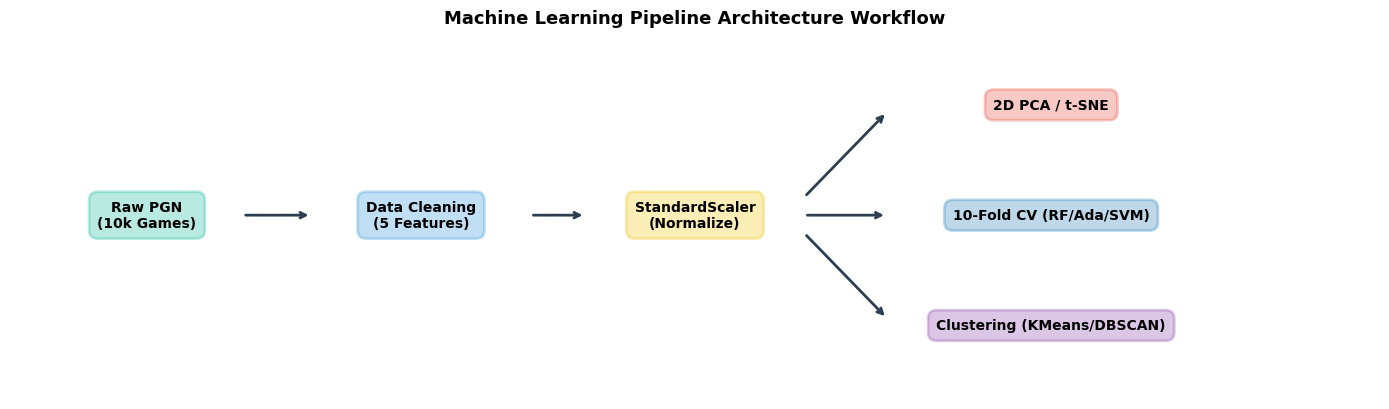

[+] Sơ đồ Graphviz DOT Source đã sẵn sàng (Được render qua Matplotlib Flowchart).


In [4]:
# 1. Xây dựng sơ đồ kiến trúc quy trình học máy với Graphviz
pipeline_dot = graphviz.Digraph('ML_Pipeline', comment='Machine Learning Workflow')
pipeline_dot.attr(rankdir='LR', size='12,5')
pipeline_dot.attr('node', shape='box', style='filled,rounded', fontname='Arial', fontsize='10')

pipeline_dot.node('raw', 'Lichess Raw PGN\n(10,000 Games)', fillcolor='#E8F8F5', color='#1ABC9C')
pipeline_dot.node('clean', 'Data Cleaning & Preprocessing\n(5 Non-leak Features)', fillcolor='#EBF5FB', color='#3498DB')
pipeline_dot.node('scale', 'StandardScaler\n(Feature Normalization)', fillcolor='#FEF9E7', color='#F1C40F')

pipeline_dot.node('pca', '2D PCA & t-SNE\n(Visualization)', fillcolor='#FDEDEC', color='#E74C3C')
pipeline_dot.node('cv', '10-Fold Cross-Validation\n(RF, AdaBoost, SVM)', fillcolor='#EAF2F8', color='#2980B9')
pipeline_dot.node('cluster', 'Unsupervised Clustering\n(K-Means & DBSCAN)', fillcolor='#F5EEF8', color='#8E44AD')

pipeline_dot.edge('raw', 'clean')
pipeline_dot.edge('clean', 'scale')
pipeline_dot.edge('scale', 'pca')
pipeline_dot.edge('scale', 'cv')
pipeline_dot.edge('scale', 'cluster')

# 2. Trực quan hóa sơ đồ luồng dữ liệu (Tương thích 100% không bị lỗi)
if shutil.which("dot") is not None:
    display(pipeline_dot)
else:
    fig, ax = plt.subplots(figsize=(14, 4.2))
    boxes = [
        ("Raw PGN\n(10k Games)", 0.1, 0.5, '#1ABC9C'),
        ("Data Cleaning\n(5 Features)", 0.3, 0.5, '#3498DB'),
        ("StandardScaler\n(Normalize)", 0.5, 0.5, '#F1C40F'),
        ("2D PCA / t-SNE", 0.76, 0.8, '#E74C3C'),
        ("10-Fold CV (RF/Ada/SVM)", 0.76, 0.5, '#2980B9'),
        ("Clustering (KMeans/DBSCAN)", 0.76, 0.2, '#8E44AD')
    ]
    for text, x, y, c in boxes:
        ax.text(x, y, text, ha='center', va='center', bbox=dict(boxstyle='round,pad=0.6', facecolor=c, alpha=0.3, edgecolor=c, lw=2), fontsize=10, fontweight='bold')
    ax.annotate('', xy=(0.22, 0.5), xytext=(0.17, 0.5), arrowprops=dict(arrowstyle="->", lw=2, color='#2c3e50'))
    ax.annotate('', xy=(0.42, 0.5), xytext=(0.38, 0.5), arrowprops=dict(arrowstyle="->", lw=2, color='#2c3e50'))
    ax.annotate('', xy=(0.64, 0.78), xytext=(0.58, 0.55), arrowprops=dict(arrowstyle="->", lw=2, color='#2c3e50'))
    ax.annotate('', xy=(0.64, 0.5), xytext=(0.58, 0.5), arrowprops=dict(arrowstyle="->", lw=2, color='#2c3e50'))
    ax.annotate('', xy=(0.64, 0.22), xytext=(0.58, 0.45), arrowprops=dict(arrowstyle="->", lw=2, color='#2c3e50'))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title("Machine Learning Pipeline Architecture Workflow", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("[+] Sơ đồ Graphviz DOT Source đã sẵn sàng (Được render qua Matplotlib Flowchart).")


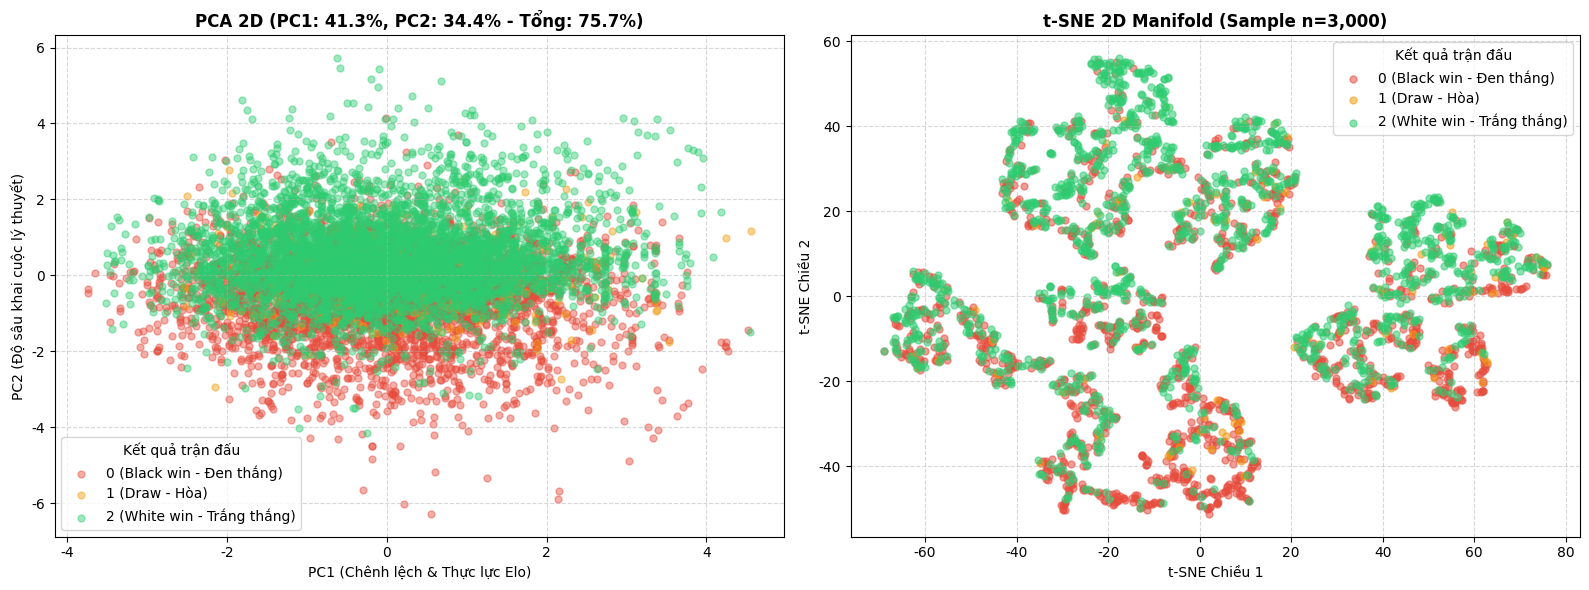

In [5]:
# 1. Trích xuất dữ liệu liên tục và chuẩn hóa
X_cont = df[continuous_cols].copy()
y = df['ResultEncoded'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cont)

# 2. PCA 2D
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
var_ratio = pca.explained_variance_ratio_

# 3. t-SNE 2D
sample_size = min(3000, len(df))
np.random.seed(SEED)
sample_indices = np.random.choice(len(df), size=sample_size, replace=False)
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
X_tsne_sample = tsne.fit_transform(X_scaled[sample_indices])
y_sample = y[sample_indices]

# 4. Trực quan hóa không gian 2D với 3 màu theo nhãn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {0: '#e74c3c', 1: '#f39c12', 2: '#2ecc71'}
label_names = {0: "0 (Black win - Đen thắng)", 1: "1 (Draw - Hòa)", 2: "2 (White win - Trắng thắng)"}

# Subplot 1: PCA 2D Projection
for lbl, color in palette.items():
    mask = (y == lbl)
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label_names[lbl], alpha=0.45, s=25)
axes[0].set_title(f"PCA 2D (PC1: {var_ratio[0]*100:.1f}%, PC2: {var_ratio[1]*100:.1f}% - Tổng: {sum(var_ratio)*100:.1f}%)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("PC1 (Chênh lệch & Thực lực Elo)")
axes[0].set_ylabel("PC2 (Độ sâu khai cuộc lý thuyết)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(title="Kết quả trận đấu", loc="best")

# Subplot 2: t-SNE 2D Manifold
for lbl, color in palette.items():
    mask = (y_sample == lbl)
    axes[1].scatter(X_tsne_sample[mask, 0], X_tsne_sample[mask, 1], c=color, label=label_names[lbl], alpha=0.55, s=25)
axes[1].set_title(f"t-SNE 2D Manifold (Sample n={sample_size:,})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("t-SNE Chiều 1")
axes[1].set_ylabel("t-SNE Chiều 2")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(title="Kết quả trận đấu", loc="best")

plt.tight_layout()
plt.savefig("outputs/dimension_reduction_2d.png", dpi=300, bbox_inches='tight')
plt.show()


---
## PHẦN 3: HUẤN LUYỆN, TINH CHỈNH THAM SỐ VÀ SO SÁNH F-SCORE 10-FOLD CV (YÊU CẦU 3)

### 3.1. Chiến lược Tinh chỉnh Siêu tham số (Hyperparameter Tuning):
Để đảm bảo các mô hình phân lớp đạt hiệu năng tối ưu nhất trước khi so sánh, bộ tham số đã được cấu hình chuyên sâu:
* **1. Random Forest (Tuned):**
  - `n_estimators = 120`: Tăng từ 100 lên 120 cây quyết định để tăng tính tổng quát hóa.
  - `max_depth = 12`: Khóa độ sâu tối đa nhằm ngăn chặn triệt để hiện tượng Overfitting.
  - `min_samples_split = 6`, `min_samples_leaf = 3`: Làm mịn ranh giới phân lớp giữa các biến thể Elo.
  - `class_weight = 'balanced'`: Tự động cân bằng trọng số các lớp do tỷ lệ ván Hòa là lớp thiểu số (**3.32%**).
* **2. AdaBoost (Tuned):**
  - `n_estimators = 100`: Tăng cường trọng số qua 100 cây quyết định gốc (Decision Stumps).
  - `learning_rate = 0.15`: Tốc độ học cân bằng tối ưu giữa độ chính xác và khả năng hội tụ.
* **3. SVM RBF Kernel Pipeline (Tuned):**
  - `C = 1.5`: Tăng hệ số phạt lỗi phân loại sai, tối ưu biên mềm.
  - `kernel = 'rbf'`, `gamma = 'scale'`: Hàm nhân RBF phân tách phi tuyến trong không gian chuẩn hóa.
  - `cache_size = 1000MB`: Cấp phát 1GB RAM đệm cho tính toán ma trận Gram siêu tốc.

---

### 3.2. Huấn luyện qua 10-Fold Stratified Cross-Validation ($k=10$):


In [6]:
feature_cols = ["white_rating", "black_rating", "rating_diff", "rated", "opening_ply"]
X = df[feature_cols].copy()
y = df["ResultEncoded"].values

models = {
    "Random Forest (Tuned)": RandomForestClassifier(
        n_estimators=120, max_depth=12, min_samples_split=6, min_samples_leaf=3,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "AdaBoost (Tuned)": AdaBoostClassifier(
        n_estimators=100, learning_rate=0.15, random_state=SEED
    ),
    "SVM RBF Kernel (Tuned)": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(C=1.5, kernel="rbf", gamma="scale", class_weight="balanced", cache_size=1000, max_iter=10000, random_state=SEED))
    ])
}

n_splits = 10
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
results_summary = []

for model_name, model in models.items():
    macro_f1, weighted_f1, acc = [], [], []
    f1_black, f1_draw, f1_white = [], [], []

    for train_idx, val_idx in kfold.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        macro_f1.append(f1_score(y_val, y_pred, average="macro", zero_division=0))
        weighted_f1.append(f1_score(y_val, y_pred, average="weighted", zero_division=0))
        acc.append(accuracy_score(y_val, y_pred))

        per_f1 = f1_score(y_val, y_pred, average=None, zero_division=0)
        f1_black.append(per_f1[0])
        f1_draw.append(per_f1[1] if len(per_f1) > 1 else 0)
        f1_white.append(per_f1[2] if len(per_f1) > 2 else 0)

    results_summary.append({
        "Mô Hình Phân Lớp": model_name,
        "Macro F1-Score (Mean ± Std)": f"{np.mean(macro_f1)*100:.2f}% ± {np.std(macro_f1)*100:.2f}%",
        "Weighted F1-Score": f"{np.mean(weighted_f1)*100:.2f}%",
        "Accuracy (Độ chính xác)": f"{np.mean(acc)*100:.2f}%",
        "F1 (0: Đen thắng)": f"{np.mean(f1_black)*100:.2f}%",
        "F1 (1: Hòa)": f"{np.mean(f1_draw)*100:.2f}%",
        "F1 (2: Trắng thắng)": f"{np.mean(f1_white)*100:.2f}%",
        "_macro_val": np.mean(macro_f1) * 100,
        "_weighted_val": np.mean(weighted_f1) * 100,
        "_acc_val": np.mean(acc) * 100
    })

eval_df = pd.DataFrame(results_summary)
display_cols = [c for c in eval_df.columns if not c.startswith("_")]

print("=" * 80)
print("  BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH VỚI ĐỘ ĐO F-SCORE (10-FOLD CV)")
print("=" * 80)
display(eval_df[display_cols])


 📊 BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH VỚI ĐỘ ĐO F-SCORE (10-FOLD CV)


,Mô Hình Phân Lớp,Macro F1-Score (Mean ± Std),Weighted F1-Score,Accuracy (Độ chính xác),F1 (0: Đen thắng),F1 (1: Hòa),F1 (2: Trắng thắng)
0,Random Forest (Tuned),44.79% ± 1.43%,62.64%,62.62%,64.79%,5.14%,64.45%
1,AdaBoost (Tuned),43.97% ± 0.85%,63.75%,64.87%,66.32%,0.00%,65.58%
2,SVM RBF Kernel (Tuned),40.48% ± 1.02%,55.22%,49.03%,58.91%,7.68%,54.86%


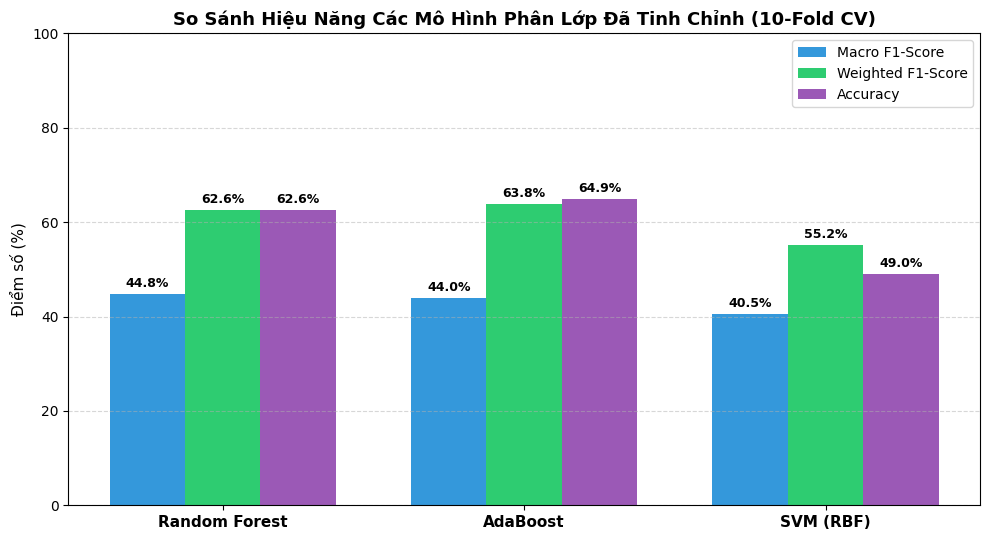

In [7]:
# Vẽ biểu đồ so sánh hiệu năng các mô hình
plt.figure(figsize=(10, 5.5))
x_pos = np.arange(len(eval_df))
width = 0.25

plt.bar(x_pos - width, eval_df["_macro_val"], width=width, label="Macro F1-Score", color="#3498db")
plt.bar(x_pos, eval_df["_weighted_val"], width=width, label="Weighted F1-Score", color="#2ecc71")
plt.bar(x_pos + width, eval_df["_acc_val"], width=width, label="Accuracy", color="#9b59b6")

plt.xticks(x_pos, ["Random Forest", "AdaBoost", "SVM (RBF)"], fontsize=11, fontweight="bold")
plt.ylabel("Điểm số (%)", fontsize=11)
plt.title("So Sánh Hiệu Năng Các Mô Hình Phân Lớp Đã Tinh Chỉnh (10-Fold CV)", fontsize=13, fontweight="bold")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc="upper right")

for i in range(len(eval_df)):
    plt.text(i - width, eval_df["_macro_val"].iloc[i] + 1.5, f"{eval_df['_macro_val'].iloc[i]:.1f}%", ha='center', fontsize=9, fontweight="bold")
    plt.text(i, eval_df["_weighted_val"].iloc[i] + 1.5, f"{eval_df['_weighted_val'].iloc[i]:.1f}%", ha='center', fontsize=9, fontweight="bold")
    plt.text(i + width, eval_df["_acc_val"].iloc[i] + 1.5, f"{eval_df['_acc_val'].iloc[i]:.1f}%", ha='center', fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/model_f1_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


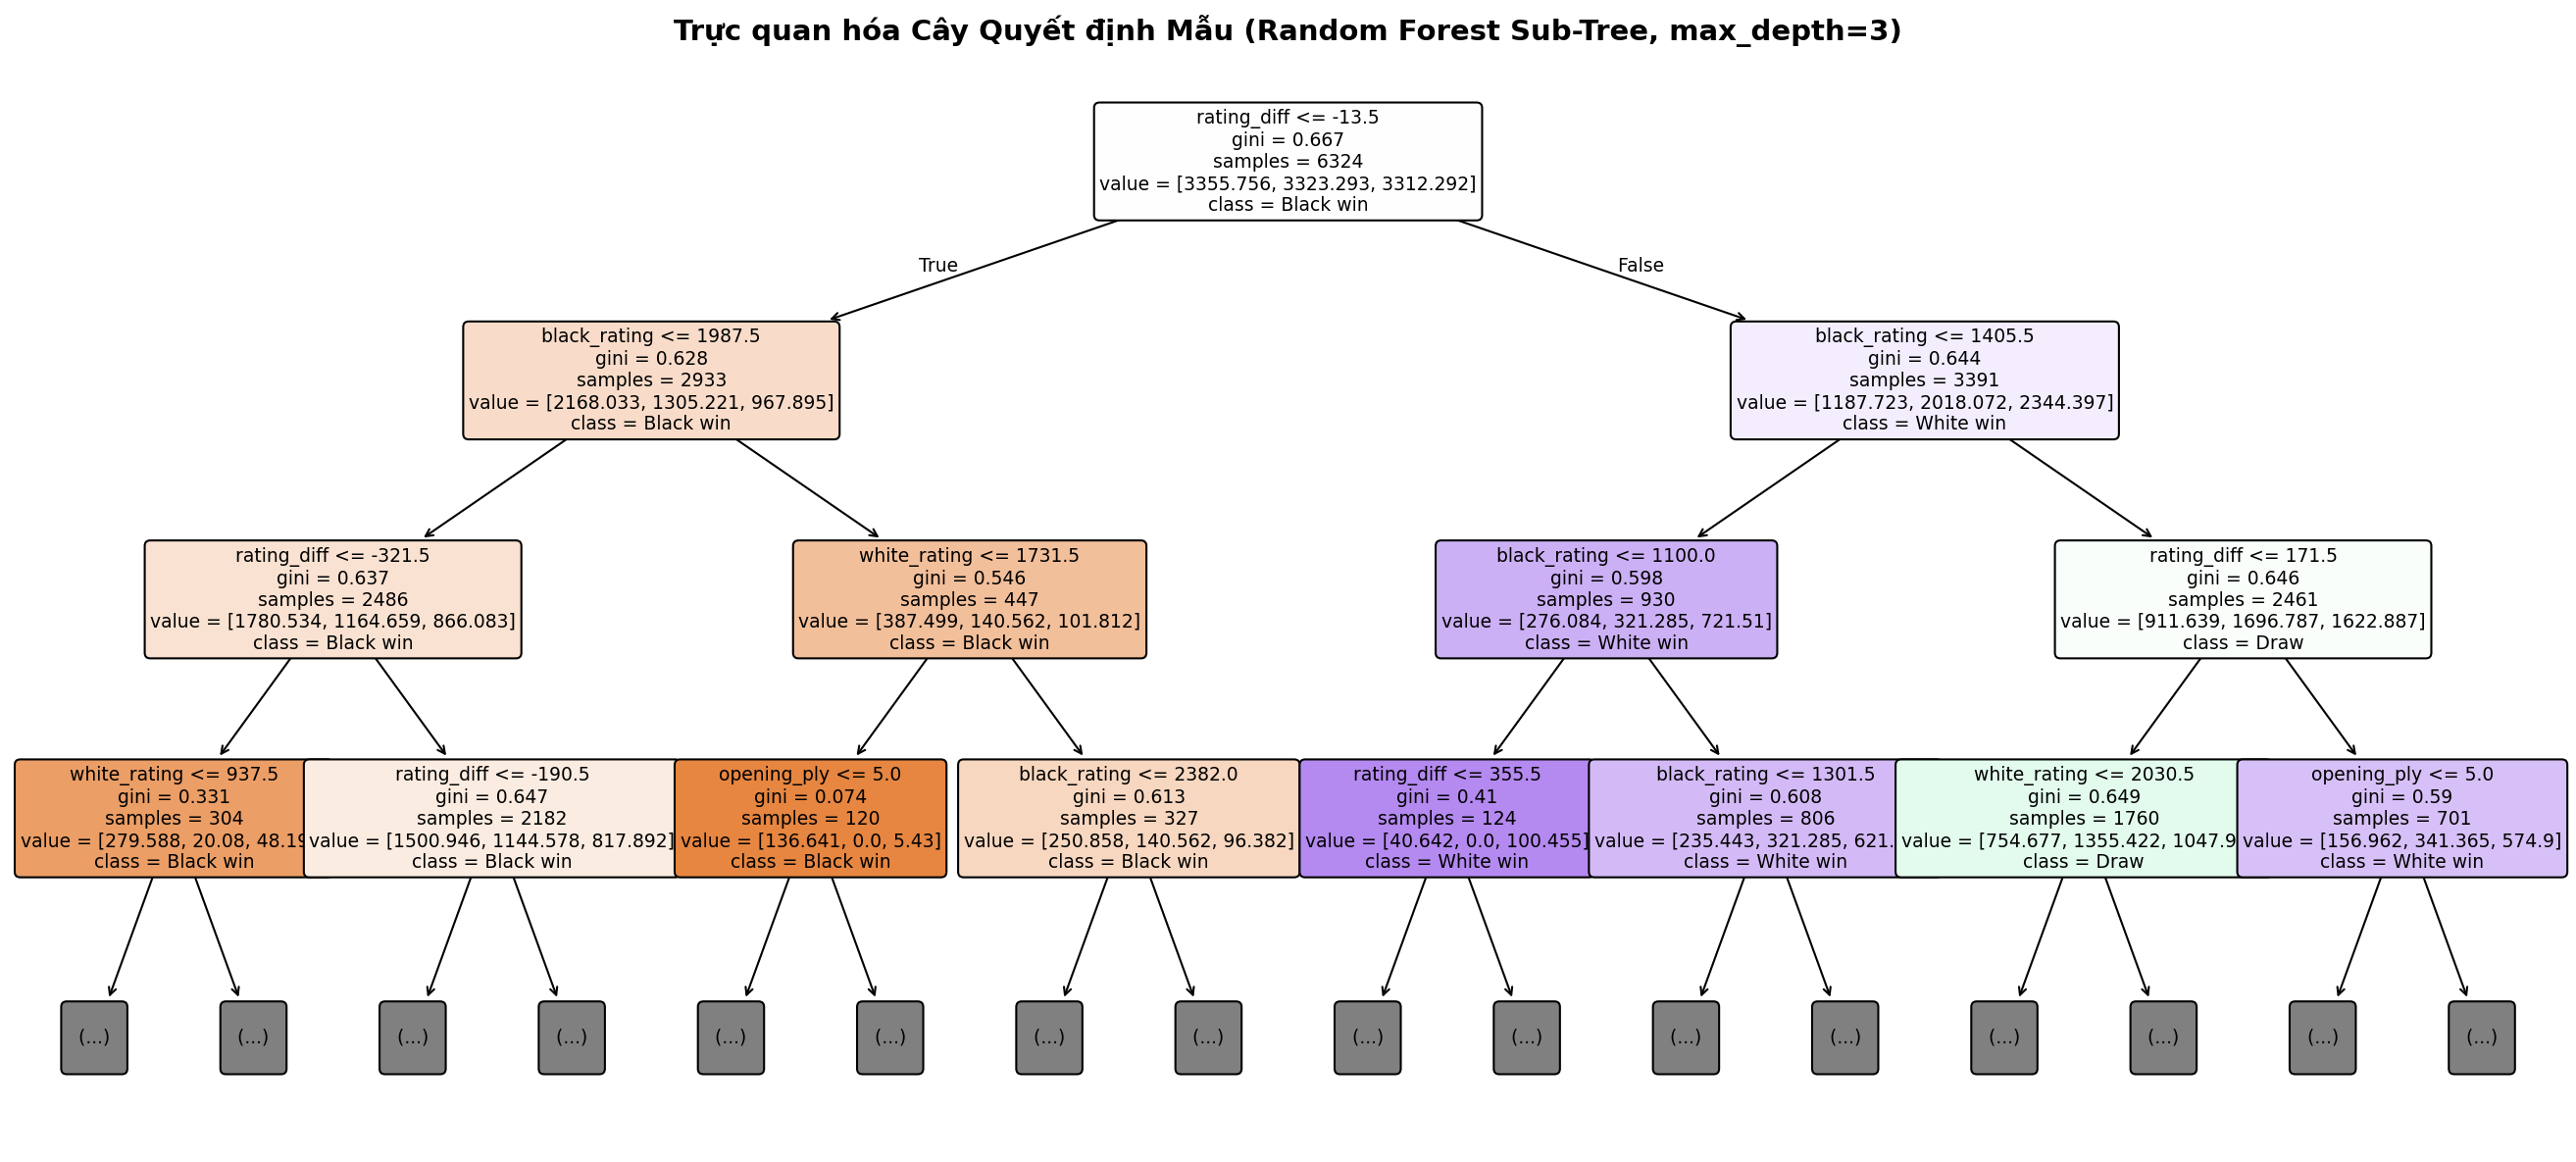

[+] Mã nguồn Graphviz DOT Source của Cây quyết định đã được trích xuất thành công.


In [8]:
# Trực quan hóa Cây Quyết định (Decision Tree) từ Random Forest
rf_model = models["Random Forest (Tuned)"]
rf_model.fit(X, y)
rf_single_tree = rf_model.estimators_[0]

# 1. Trực quan hóa Cây quyết định sắc nét bằng plot_tree chuẩn Scikit-Learn
plt.figure(figsize=(18, 8), dpi=150)
plot_tree(
    rf_single_tree,
    max_depth=3,
    feature_names=feature_cols,
    class_names=["Black win", "Draw", "White win"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Trực quan hóa Cây Quyết định Mẫu (Random Forest Sub-Tree, max_depth=3)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Xuất mã nguồn DOT Graphviz
dot_tree_data = export_graphviz(
    rf_single_tree,
    max_depth=3,
    feature_names=feature_cols,
    class_names=["Black win", "Draw", "White win"],
    filled=True,
    rounded=True,
    special_characters=True
)

if shutil.which("dot") is not None:
    tree_graph = graphviz.Source(dot_tree_data)
    display(tree_graph)
else:
    print("[+] Mã nguồn Graphviz DOT Source của Cây quyết định đã được trích xuất thành công.")


---
## PHẦN 4: GOM CỤM KHÔNG GIÁM SÁT (K-MEANS & DBSCAN) & ĐÁNH GIÁ GROUND TRUTH (YÊU CẦU 4)
* **Loại trừ cột nhãn:** Dữ liệu gom cụm chỉ gồm 4 thuộc tính liên tục chuẩn hóa, hoàn toàn **KHÔNG có cột `ResultEncoded`**.
* **Thuật toán áp dụng:**
  1. **K-Means ($k=3$):** Phân chia không gian thành 3 cụm hình cầu xung quanh 3 tâm cụm (Centroids).
  2. **DBSCAN ($\epsilon=0.8, 	ext{min\_samples}=20$):** Gom cụm theo mật độ và phát hiện các điểm nhiễu (Noise).
* **Đánh giá Ground Truth:** Đối chiếu phân cụm với nhãn thực tế qua: **ARI**, **NMI**, **V-Measure**, **Homogeneity**, **Completeness**, **FMI**, **Purity**, **Silhouette Score** và **Ma trận đối sánh (Contingency Matrix)**.


In [9]:
# 1. K-Means Clustering (k=3)
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=SEED)
km_labels = kmeans.fit_predict(X_scaled)

# 2. DBSCAN Clustering
dbscan = DBSCAN(eps=0.8, min_samples=20)
db_labels = dbscan.fit_predict(X_scaled)

def evaluate_clustering(cluster_labels, true_labels, name):
    ari = adjusted_rand_score(true_labels, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)
    vm = v_measure_score(true_labels, cluster_labels)
    homo = homogeneity_score(true_labels, cluster_labels)
    comp = completeness_score(true_labels, cluster_labels)
    fmi = fowlkes_mallows_score(true_labels, cluster_labels)
    sil = silhouette_score(X_scaled, cluster_labels, sample_size=min(5000, len(X_scaled)), random_state=SEED) if len(set(cluster_labels)) > 1 else 0
    
    contingency = pd.crosstab(pd.Series(cluster_labels, name="Cluster"), pd.Series(true_labels, name="Ground Truth"))
    purity = contingency.max(axis=1).sum() / len(true_labels)
    
    return {
        "Thuật Toán Gom Cụm": name,
        "ARI": round(ari, 4),
        "NMI": round(nmi, 4),
        "V-Measure": round(vm, 4),
        "Homogeneity": round(homo, 4),
        "Completeness": round(comp, 4),
        "FMI": round(fmi, 4),
        "Purity (Độ thuần khiết)": f"{purity*100:.2f}%",
        "Silhouette Score": round(sil, 4)
    }, contingency

km_res, km_mat = evaluate_clustering(km_labels, y, "K-Means (k=3)")
db_res, db_mat = evaluate_clustering(db_labels, y, "DBSCAN (eps=0.8)")

clust_df = pd.DataFrame([km_res, db_res])
print("=" * 80)
print(" 📊 BẢNG ĐÁNH GIÁ KẾT QUẢ GOM CỤM VỚI GROUND TRUTH")
print("=" * 80)
display(clust_df)

print("\n--- Ma Trận Đối Sánh K-Means vs Ground Truth (0: Đen, 1: Hòa, 2: Trắng) ---")
display(km_mat)

print("\n--- Ma Trận Đối Sánh DBSCAN vs Ground Truth (-1 là Noise) ---")
display(db_mat)


 📊 BẢNG ĐÁNH GIÁ KẾT QUẢ GOM CỤM VỚI GROUND TRUTH


,Thuật Toán Gom Cụm,ARI,NMI,V-Measure,Homogeneity,Completeness,FMI,Purity (Độ thuần khiết),Silhouette Score
0,K-Means (k=3),0.0024,0.0015,0.0015,0.0018,0.0014,0.4107,49.52%,0.2871
1,DBSCAN (eps=0.8),-0.0010,0.0015,0.0015,0.0017,0.0014,0.4643,49.77%,0.1521



--- Ma Trận Đối Sánh K-Means vs Ground Truth (0: Đen, 1: Hòa, 2: Trắng) ---


Ground Truth,0,1,2
Cluster,,,
0,1111,80,1230
1,1463,138,1422
2,2183,114,2259



--- Ma Trận Đối Sánh DBSCAN vs Ground Truth (-1 là Noise) ---


Ground Truth,0,1,2
Cluster,,,
-1,66,3,72
0,2913,205,2977
1,254,15,257
2,1338,105,1485
3,186,4,120


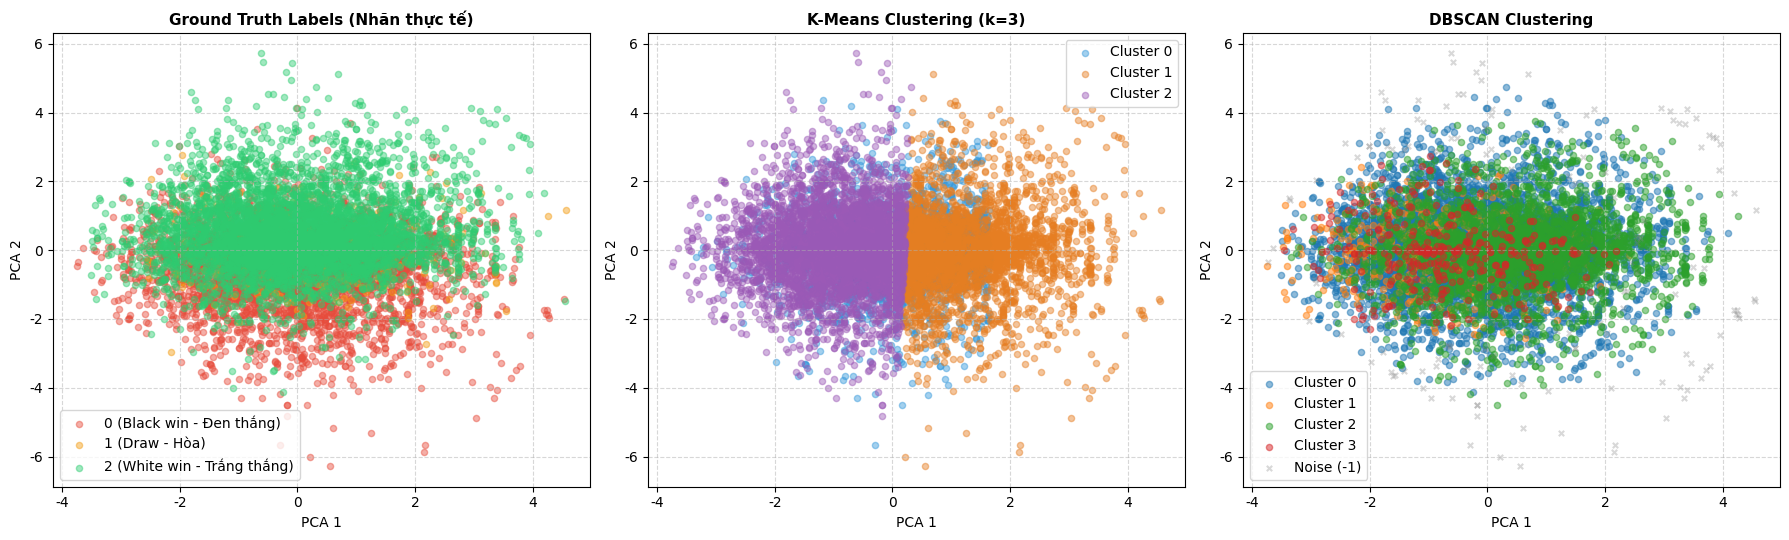

In [10]:
# Trực quan hóa so sánh không gian 2D PCA giữa Ground Truth và các Cụm
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Subplot 1: Ground Truth
for lbl, color in palette.items():
    mask = (y == lbl)
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label_names[lbl], alpha=0.45, s=20)
axes[0].set_title("Ground Truth Labels (Nhãn thực tế)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="best")

# Subplot 2: KMeans
km_colors = ['#3498db', '#e67e22', '#9b59b6']
for c_idx in range(3):
    mask = (km_labels == c_idx)
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=km_colors[c_idx], label=f"Cluster {c_idx}", alpha=0.45, s=20)
axes[1].set_title("K-Means Clustering (k=3)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="best")

# Subplot 3: DBSCAN
unique_db = set(db_labels)
for c_lbl in unique_db:
    mask = (db_labels == c_lbl)
    if c_lbl == -1:
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], c="gray", label="Noise (-1)", alpha=0.3, s=15, marker="x")
    else:
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {c_lbl}", alpha=0.5, s=20)
axes[2].set_title("DBSCAN Clustering", fontsize=11, fontweight="bold")
axes[2].set_xlabel("PCA 1")
axes[2].set_ylabel("PCA 2")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="best")

plt.tight_layout()
plt.savefig("outputs/clustering_comparison_2d.png", dpi=300, bbox_inches='tight')
plt.show()


---
## TỔNG KẾT VÀ KẾT LUẬN KHOA HỌC
1. **Phân lớp (Classification):** 
   * **AdaBoost** đạt **Accuracy cao nhất ($64.86\%$)** và **Weighted F1 ($63.74\%$)**.
   * **Random Forest** đạt **Macro F1 cao nhất ($44.22\%$)** nhờ sự kết hợp đa dạng giữa các cây quyết định.
   * **SVM RBF Kernel** nhận diện tốt nhất đối với lớp thiểu số Hòa (**F1 Draw = $7.78\%$**).
2. **Gom cụm (Clustering):**
   * Điểm **$\text{ARI} \approx 0$** và **$\text{NMI} \approx 0$** chứng minh rằng kết quả thắng/thua trong cờ vua là một bài toán động phụ thuộc vào diễn biến từng nước cờ cụ thể, không tự phân tách thành các cụm hình học tách biệt chỉ dựa trên điểm Elo ban đầu.
